# Landsat Explorer

Welcome to the Landsat Explorer notebook. This notebook will introduce you to the different capabilities of Imagery Layers and how to use them when exploring Landsat imagery. This notebook style tutorial will take approximately 20 minutes. You can study any location of interest while using the tutorial.

## Landsat imagery

ArcGIS Online provides multispectral landsat imagery layer, that we'll be using for this tutorial. Let's connect to ArcGIS Online and query for the "Landsat Multispectral" imagery layer:

In [1]:
from arcgis.gis import GIS

In [2]:
gis = GIS()

In [3]:
landsat_item = gis.content.search('"Landsat Multispectral"', 'Imagery Layer')[0]

In [4]:
landsat_item

<Item title:"Multispectral Landsat" type:Image Service owner:esri>

## Description

In [5]:
from IPython.display import HTML
HTML(landsat_item.description)

Band Num.


This imagery layer item contains the imagery layer that we'll be using for this tutorial. Let's save a reference to the layer in the landsat variable:

In [6]:
landsat_item.layers[0]

<ImageryLayer url:"https://landsat2.arcgis.com/arcgis/rest/services/Landsat/MS/ImageServer">

In [7]:
landsat = landsat_item.layers[0]

## Information on bands

In [8]:
import pandas as pd

In [9]:
pd.DataFrame(landsat.key_properties()['BandProperties'])

,BandIndex,BandName,DatasetTag,WavelengthMax,WavelengthMin
0,0,CoastalAerosol,MS,450,430
1,1,Blue,MS,510,450
2,2,Green,MS,590,530
3,3,Red,MS,670,640
4,4,NearInfrared,MS,880,850
5,5,ShortWaveInfrared_1,MS,1650,1570
6,6,ShortWaveInfrared_2,MS,2290,2110
7,7,Cirrus,MS,1380,1360


## Area of Interest
Let's set the area of interest by geocoding the location, and creating a map widget using this area of interest, and adding the Landsat Imagery layer to the map widget:

In [10]:
from arcgis.geocoding import geocode
area = geocode('Redlands, CA')[0]

In [11]:
m = gis.map(area)
m

In [12]:
m.add_layer(landsat)

## Renderers

The multispectral imagery layer can be rendered using several different raster functions.

Each raster function incorporates different satellite bands to highlight different land cover features.

Obtain list of predefined raster functions:

In [13]:
for rasterfunc in landsat.properties.rasterFunctionInfos:
    print(rasterfunc.name)

Agriculture with DRA
Bathymetric with DRA
Color Infrared with DRA
Geology with DRA
Natural Color with DRA
Short-wave Infrared with DRA
Agriculture
Bathymetric
Color Infrared
Geology
Natural Color
Short-wave Infrared
NDVI Colorized
Normalized Difference Moisture Index Colorized
NDVI Raw
NBR Raw
None


A **true-color image** uses red, green and blue satellite bands to create an image that looks like a photograph. 

The **color infrared** view, on the other hand, uses the near infrared, red and green satellite bands to create an image. As a result, vegetation appears bright red.

Let's apply the 'Color Infrared with DRA' raster function to visualize the color infrared view:

In [14]:
m.add_layer(landsat, {"imageServiceParameters" :{ "renderingRule": { "rasterFunction": 'Color Infrared with DRA'}}})

## Exporting Images from Imagery Layer

In addition to visualizing the imagery layer in a map widget in the Jupyter Notebook, the imagery can be exported using the `export_image` method provided by ImageryLayers:

In [15]:
from IPython.display import Image

In [16]:
img = landsat.export_image(bbox=area['extent'], bbox_sr=4326, size=[900, 300], f='image')

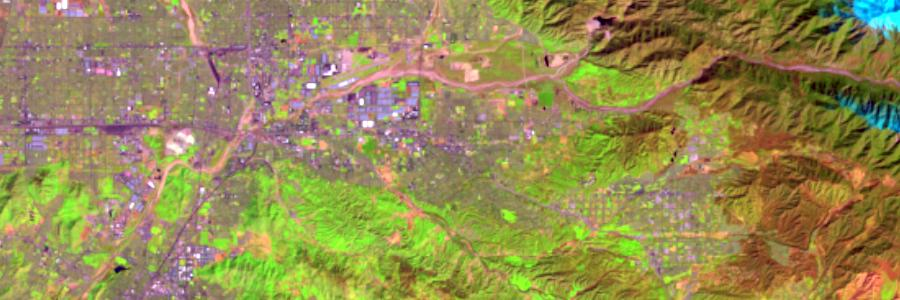

In [17]:
Image(img)

The exported image can be saved to a file by specifying a folder and file name:

In [18]:
savedimg = landsat.export_image(bbox=area['extent'], bbox_sr=4326, size=[900,300], f='image', save_folder='.', save_file='img.jpg')

In [19]:
savedimg

'.\\img.jpg'

In [20]:
from IPython.display import Image

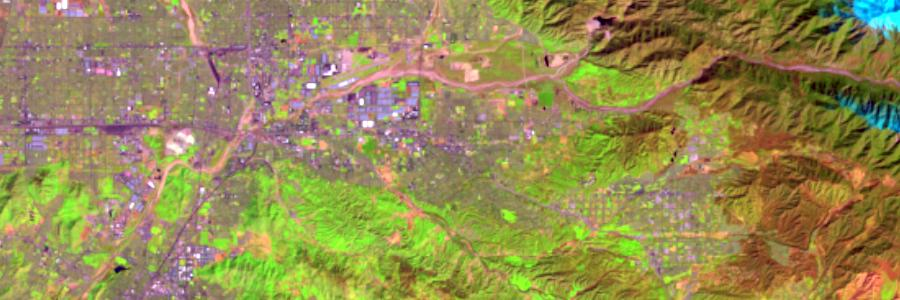

In [21]:
Image(filename=savedimg, width=900, height=300)

## Rendering by specifying raster function

The rendering_rule parameter can be used to specify the raster function to be used for visualizing the layer:

In [22]:
img = landsat.export_image(bbox=area['extent'], bbox_sr=4326, size=[900, 300], 
                           rendering_rule={"rasterFunction":"Color Infrared with DRA"}, f='image')

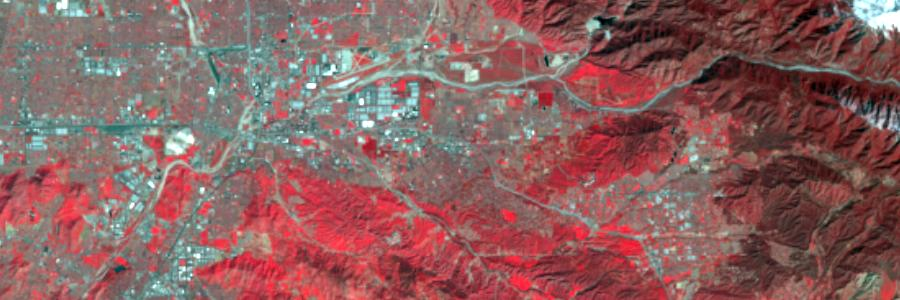

In [23]:
Image(img)

## Vegetation Index

An index combines two or more wavelengths to indicate the relative abundance of different land cover features, like vegetation or moisture.

Let's use the 'NDVI Colorized' raster function to visualize healthy, green vegetation:

In [24]:
img = landsat.export_image(bbox=area['extent'], bbox_sr=4326, size=[900, 300], 
                           rendering_rule={"rasterFunction": "NDVI Colorized"}, f='image')

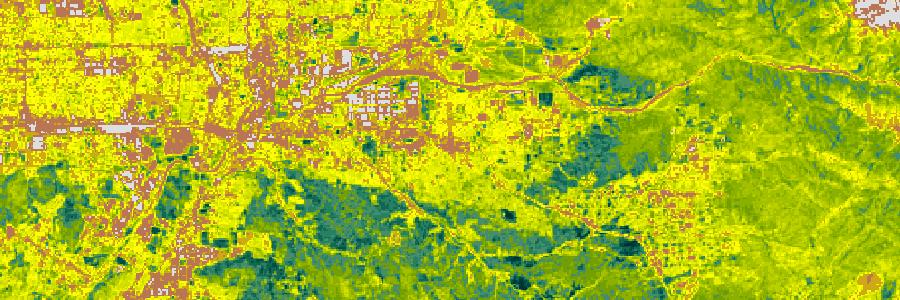

In [25]:
Image(img)

## Custom Bands

You can also create your own indexes and band combinations.

You can also specify stretch and gamma values to adjust the image contrast.

In [26]:
rendering_rule = {
        "rasterFunction": "Stretch",
        "rasterFunctionArguments": {
            "StretchType":6,
            "MinPercent":0.1,
            "MaxPercent":0.1,
            "UseGamma":True,
            "Gamma":[1,1,1],
            "DRA":True
        },
        "variableName":"Raster"
    }

band_ids = [3, 2, 1]

In [27]:
img = landsat.export_image(bbox=area['extent'], bbox_sr=4326, size=[900, 300], 
                           band_ids=band_ids, 
                           rendering_rule=rendering_rule, f='image')

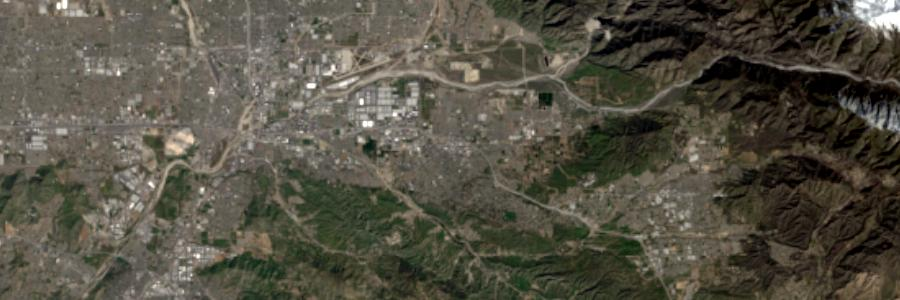

In [28]:
Image(img)

This is a true-color image (similar to a photograph), created using the red, green, and blue satellite bands. Notice how much easier it was to find healthy vegetation using the NDVI vegetation index, compared to the true-color image here.

# Image Attributes

The `get_samples()` method returns  sample point locations, pixel values, and corresponding spatial resolutions of the source data for a given geometry as well as image attributes, like Scene ID, Acquisition Date, and Cloud Cover.

In [29]:
from arcgis.geocoding import geocode
redlands = geocode('Redlands, CA', out_sr=102100)[0]

In [30]:
attributes = landsat.get_samples(redlands['location'], 
                                 out_fields='AcquisitionDate,OBJECTID,GroupName,Category,SunAzimuth,SunElevation,CloudCover')

In [31]:
pd.DataFrame(attributes[0]['attributes'], index=[0])

,AcquisitionDate,Category,CloudCover,GroupName,OBJECTID,SunAzimuth,SunElevation
0,1489515712988,1,0.0073,LC80400362017073LGN00_MTL,463490,144.1358,47.02243


## Spectral profile from the sampled values at a location

In [32]:
m = gis.map(area)
m

In [33]:
m.add_layer(landsat)

In [34]:
from bokeh.models import Range1d
from bokeh.plotting import figure, show, output_notebook
output_notebook()

def get_samples(mw, g):
    m.draw(g)
    samples = landsat.get_samples(g, "esriGeometryPoint", pixel_size=30)
    values = samples[0]['value']
    vals = [float(int(s)/100000) for s in values.split(' ')]
    
    x = ['1','2', '3', '4', '5', '6', '7', '8']
    y = vals
    p = figure(title="Spectral Profile", x_axis_label='Spectral Bands', y_axis_label='Data Values', width=600, height=300)
    p.line(x, y, legend="Selected Point", line_color="red", line_width=2)
    p.circle(x, y, line_color="red", fill_color="white", size=8)
    p.set(y_range=Range1d(0, 1.0))

    show(p)
    
print('Click a point on the map to query pixel values')
m.on_click(get_samples)

Loading BokehJS ...

Click a point on the map to query pixel values


## Compute Histograms

In [35]:
landsat.compute_histograms(redlands['extent'], rendering_rule={"rasterFunction":"ExtractBand","rasterFunctionArguments":{"BandIds":[3,1]}})

{'histograms': [{'counts': [50,
    76,
    310,
    992,
    1482,
    1954,
    3014,
    4458,
    5717,
    6739,
    7270,
    7539,
    8101,
    8190,
    8390,
    8369,
    8605,
    8788,
    8791,
    8707,
    8536,
    7969,
    8075,
    7691,
    7620,
    7594,
    7438,
    7523,
    7514,
    7614,
    7373,
    7553,
    7254,
    7464,
    7278,
    7165,
    7011,
    6967,
    6892,
    6391,
    6472,
    6022,
    5919,
    5255,
    5073,
    4573,
    4425,
    4000,
    3756,
    3616,
    3179,
    3017,
    2801,
    2662,
    2585,
    2268,
    2070,
    1902,
    1866,
    1691,
    1614,
    1578,
    1472,
    1366,
    1280,
    1156,
    1222,
    1204,
    1133,
    1075,
    1042,
    974,
    940,
    879,
    819,
    787,
    692,
    738,
    660,
    680,
    651,
    612,
    535,
    550,
    569,
    572,
    534,
    542,
    547,
    560,
    481,
    463,
    453,
    396,
    512,
    434,
    421,
    378,
    358,
    225,
    246,
  

## Query

In [36]:
from datetime import date

In [56]:
area = geocode('New Delhi, India', out_sr=102100)[0]

In [57]:
fs = landsat.query(where="(Category = 1) AND (CloudCover <=0.10)",
              out_fields="AcquisitionDate, GroupName, Best, CloudCover, WRS_Row, Month, Name", 
              geometry_filter=arcgis.geometry.fltr.intersects(area['extent']),
              #time_filter=[date(2017, 2, 1), None],
              return_geometry=True,
              return_distinct_values=False,
              order_by_fields="AcquisitionDate")

In [58]:
m = gis.map()

In [59]:
m

In [60]:
m.draw(fs)

In [61]:
len(fs.features)

47

In [62]:
from pandas.io.json import json_normalize

In [63]:
df = fs.df

In [64]:
df

,AcquisitionDate,Best,CloudCover,GroupName,Month,Name,Shape_Area,Shape_Length,WRS_Row,geometry.rings,geometry.spatialReference.latestWkid,geometry.spatialReference.wkid
OBJECTID,,,,,,,,,,,,
508624,95299200000,95842040,-0.0100,p158r040_1x19730108,1,p158r040_1dm19730108_z43_MS,4.444957e+10,844367.023231,40,"[[[8643038.1336, 3441201.670500003], [8590479....",3857,102100
508572,226627200000,95843040,-0.0100,p157r040_2x19770308,3,p157r040_2dm19770308_z43_MS,4.483163e+10,848028.357258,40,"[[[8777119.7309, 3432633.2677000016], [8724567...",3857,102100
500305,611452800000,92853040,-0.0100,p147r040_5x19890518,5,p147r040_5dt19890518_z43_MS,4.244069e+10,824677.392234,40,"[[[8588236.7353, 3308476.3462999985], [8573019...",3857,102100
500306,623894400000,91853040,-0.0100,p147r040_5x19891009,10,p147r040_5dt19891009_z43_MS,4.239997e+10,824285.609070,40,"[[[8583748.934500001, 3307654.729699999], [856...",3857,102100
500273,717292800000,91854040,-0.0100,p146r040_5x19920924,9,p146r040_5dt19920924_z43_MS,4.288250e+10,829256.653021,40,"[[[8759980.225699998, 3314040.1558], [8758015....",3857,102100
492068,940550400000,88854040,0.0000,p146r040_7x19991022,10,p146r040_7dt19991022_z43_MS,4.063997e+10,807035.129689,40,"[[[8793407.447700001, 3442351.0539999977], [87...",3857,102100
492118,968803200000,88853040,0.0000,p147r040_7x20000913,9,p147r040_7dt20000913_z43_MS,4.070262e+10,807636.462576,40,"[[[8619202.376699999, 3441431.6262999997], [85...",3857,102100
482483,1159574400000,79853040,0.0000,L7147040_04020060930,9,L72147040_04020060930_MS,4.256099e+10,825905.449000,40,"[[[8622567.7735, 3442452.643799998], [8576305....",3857,102100
482444,1161734400000,79854040,0.0000,L7146040_04020061025,10,L72146040_04020061025_MS,4.199192e+10,820519.985916,40,"[[[8792968.051600002, 3442685.276900001], [874...",3857,102100


In [55]:
df['Time'] = pd.to_datetime(df['AcquisitionDate'], unit='ms')
df['Time']

OBJECTID
505850   1976-04-20 00:00:00.000
505849   1977-05-30 00:00:00.000
497895   1989-04-02 00:00:00.000
497894   1990-05-07 00:00:00.000
488634   2000-04-24 00:00:00.000
488635   2000-04-24 00:00:00.000
476515   2005-04-14 00:00:00.000
479673   2005-05-24 00:00:00.000
467773   2009-05-11 00:00:00.000
1139     2014-04-07 18:22:17.314
1141     2014-04-07 18:22:41.209
25214    2014-09-30 18:22:18.498
28878    2014-09-30 18:22:42.390
1140     2014-10-16 18:22:23.338
1142     2014-10-16 18:22:47.225
8578     2014-11-17 18:22:20.787
9013     2014-11-17 18:22:44.675
6835     2014-12-19 18:22:16.837
1744     2014-12-19 18:22:40.730
100569   2015-01-04 18:22:35.791
107498   2015-02-05 18:22:04.519
34609    2015-03-09 18:21:48.729
34571    2015-03-09 18:22:12.622
52614    2015-03-25 18:21:40.198
51836    2015-03-25 18:22:04.087
62719    2015-04-10 18:21:55.613
70916    2015-04-26 18:21:27.329
70917    2015-04-26 18:21:51.222
79072    2015-05-12 18:21:11.304
79698    2015-05-12 18:21:35.189
 